# SmartCollegeBot: An NLP & ML-Based College Assistant Chatbot

This notebook shows a beginner-friendly project using Natural Language Processing and Machine Learning to build a college assistant chatbot. The project uses an intents dataset and classic ML models so it is easy to understand and extend.

## Project Introduction

SmartCollegeBot is a simple chatbot designed to answer college-related questions using intents, text preprocessing, and machine learning. It can help students with admissions, fees, schedules, library hours, campus clubs, and other common campus queries.

## Objectives

- Build a chatbot using NLP and machine learning.
- Understand intent classification with a dataset of patterns and responses.
- Preprocess text data using NLTK.
- Train simple ML models and compare their performance.
- Save the trained model and vectorizer for future use.

## Technologies Used

- Python
- NLTK
- scikit-learn
- pandas
- numpy
- matplotlib
- seaborn
- Streamlit (for a separate UI)

In [1]:
# Import required libraries
import json
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize

In [2]:
# Download NLTK resources if needed
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\Komal
[nltk_data]     anand\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Komal
[nltk_data]     anand\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# Load the intents dataset from a JSON file
with open('intents.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

# Show the structure of the dataset
print('Loaded intents:', len(data['intents']))
print('Sample intent keys:', [intent['tag'] for intent in data['intents']][:5])

Loaded intents: 10
Sample intent keys: ['greeting', 'goodbye', 'thanks', 'ask_courses', 'ask_deadline']


In [4]:
# Convert patterns and tags into a dataframe for easier analysis
records = []
for intent in data['intents']:
    for pattern in intent['patterns']:
        records.append({
            'text': pattern,
            'intent': intent['tag']
        })

df = pd.DataFrame(records)

df.head()

,text,intent
0,Hi,greeting
1,Hello,greeting
2,Hey,greeting
3,Good morning,greeting
4,Good evening,greeting


## Exploratory Data Analysis (EDA)

We explore the dataset shape, intent distribution, and the length of user queries. This helps us understand the data before training the model.

In [5]:
# Basic dataset overview
print('Dataset shape:', df.shape)
print('Unique intents:', df['intent'].nunique())
print('Intent counts:')
print(df['intent'].value_counts())

Dataset shape: (50, 2)
Unique intents: 10
Intent counts:
intent
greeting         5
goodbye          5
thanks           5
ask_courses      5
ask_deadline     5
ask_fees         5
ask_library      5
ask_clubs        5
ask_transport    5
noanswer         5
Name: count, dtype: int64


C:\Users\Komal anand\AppData\Local\Temp\ipykernel_26232\4128267048.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='intent', palette='Set2')


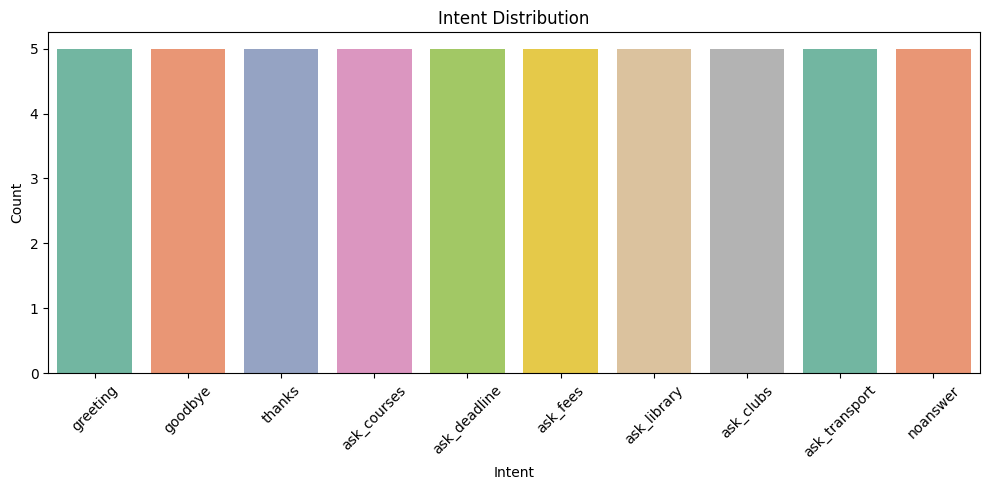

In [6]:
# Create a simple bar chart of intent distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='intent', palette='Set2')
plt.title('Intent Distribution')
plt.xlabel('Intent')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# Analyze text length to see how long patterns are
df['text_length'] = df['text'].apply(lambda x: len(x.split()))
print(df[['text', 'text_length']].head())
print('Average words per pattern:', df['text_length'].mean())

           text  text_length
0            Hi            1
1         Hello            1
2           Hey            1
3  Good morning            2
4  Good evening            2
Average words per pattern: 3.6


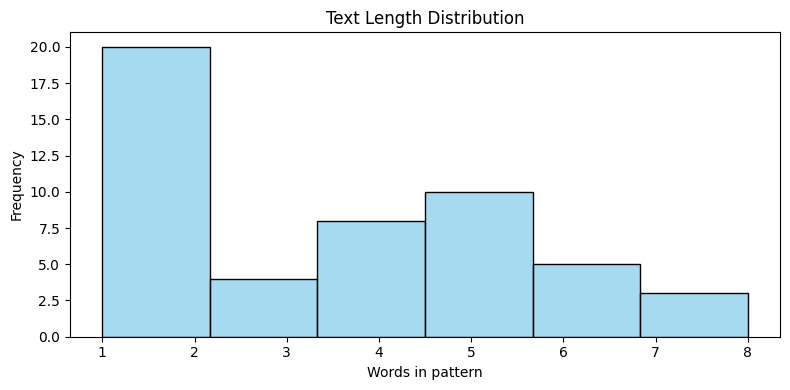

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df['text_length'], bins=6, color='skyblue')
plt.title('Text Length Distribution')
plt.xlabel('Words in pattern')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## NLP Preprocessing

We clean the text by lowercasing, tokenizing, removing stopwords, and applying stemming. This makes the text easier for the model to understand.

In [9]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    text = text.lower()
    tokens = word_tokenize(text)
    clean_tokens = []
    for token in tokens:
        if token.isalpha() and token not in stop_words:
            stemmed = stemmer.stem(token)
            clean_tokens.append(stemmed)
    return ' '.join(clean_tokens)

# Test the preprocessing function
sample = 'What is the admission deadline?'
print('Original:', sample)
print('Processed:', preprocess_text(sample))

Original: What is the admission deadline?
Processed: admiss deadlin


In [10]:
# Apply preprocessing to the entire dataset
df['clean_text'] = df['text'].apply(preprocess_text)
df.head()

,text,intent,text_length,clean_text
0,Hi,greeting,1,hi
1,Hello,greeting,1,hello
2,Hey,greeting,1,hey
3,Good morning,greeting,2,good morn
4,Good evening,greeting,2,good even


## Feature Engineering

We use TF-IDF vectorization to convert text into numbers. TF-IDF helps the model focus on important words while reducing the effect of words that appear often in all patterns.

In [11]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_text'])
y = df['intent']

print('Feature matrix shape:', X.shape)
print('Number of unique intents:', len(y.unique()))

Feature matrix shape: (50, 65)
Number of unique intents: 10


In [12]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Training samples:', X_train.shape[0])
print('Test samples:', X_test.shape[0])

Training samples: 40
Test samples: 10


## Train Machine Learning Models

We train two simple models: Naive Bayes and Logistic Regression. These models work well for text classification tasks and are easy to understand.

In [13]:
# Train Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [14]:
# Evaluate both models on the test set
models = {'Naive Bayes': nb_model, 'Logistic Regression': lr_model}
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    results.append({
        'Model': name,
        'Accuracy': round(accuracy, 3),
        'Precision': round(report['weighted avg']['precision'], 3),
        'Recall': round(report['weighted avg']['recall'], 3),
        'F1-score': round(report['weighted avg']['f1-score'], 3)
    })
    print('---', name, '---')
    print(classification_report(y_test, y_pred, zero_division=0))

--- Naive Bayes ---
               precision    recall  f1-score   support

    ask_clubs       1.00      1.00      1.00         1
  ask_courses       1.00      1.00      1.00         1
 ask_deadline       0.00      0.00      0.00         1
     ask_fees       1.00      1.00      1.00         1
  ask_library       1.00      1.00      1.00         1
ask_transport       1.00      1.00      1.00         1
      goodbye       0.00      0.00      0.00         1
     greeting       0.20      1.00      0.33         1
     noanswer       0.00      0.00      0.00         1
       thanks       0.00      0.00      0.00         1

     accuracy                           0.60        10
    macro avg       0.52      0.60      0.53        10
 weighted avg       0.52      0.60      0.53        10

--- Logistic Regression ---
               precision    recall  f1-score   support

    ask_clubs       1.00      1.00      1.00         1
  ask_courses       1.00      1.00      1.00         1
 ask_deadline

In [15]:
# Show a comparison table of the metrics
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,0.6,0.52,0.6,0.533
1,Logistic Regression,0.6,0.52,0.6,0.533


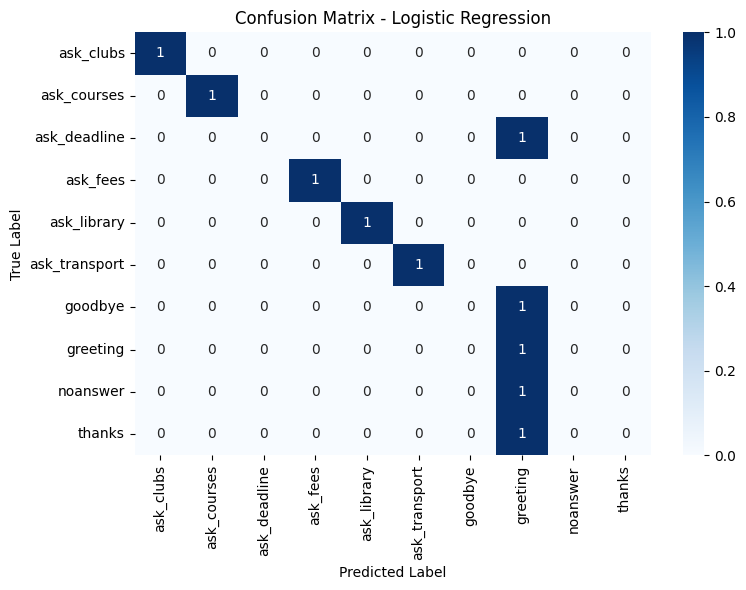

In [16]:
# Confusion matrix for the better model (Logistic Regression)
best_model = lr_model
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best, labels=best_model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Unsupervised Learning (Bonus)

We also try KMeans clustering on the TF-IDF vectors to see how the patterns group together without using labels. PCA is used to visualize the clusters in 2D.

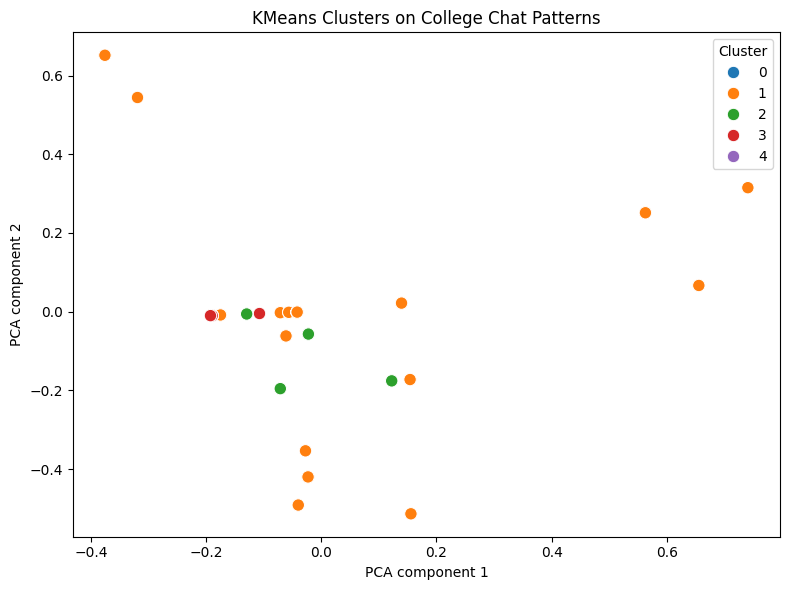

In [17]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X.toarray())

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='tab10', s=80)
plt.title('KMeans Clusters on College Chat Patterns')
plt.xlabel('PCA component 1')
plt.ylabel('PCA component 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## Chatbot Function

We build a simple function to preprocess a user question, predict the intent, and return a response. If the model is not confident, the bot returns a fallback answer.

In [18]:
def get_response(message, model, vectorizer, threshold=0.3):
    processed = preprocess_text(message)
    vector = vectorizer.transform([processed])
    probabilities = model.predict_proba(vector)[0]
    best_index = np.argmax(probabilities)
    confidence = probabilities[best_index]            
    intent = model.classes_[best_index]

    if confidence < threshold:
        return 'Sorry, I could not understand your query properly.'

    for item in data['intents']:
        if item['tag'] == intent:
            return np.random.choice(item['responses'])

    return 'Sorry, I could not understand your query properly.'

# Test the chatbot function with a few questions
questions = [
    'What is the application deadline?',
    'Hello, can you help me?',
    'Do you have a library?',
    'Tell me about college fees.'
]
for question in questions:
    print('User:', question)
    print('Bot:', get_response(question, lr_model, vectorizer))
    print()

User: What is the application deadline?
Bot: The last date to apply is usually the last day of May.

User: Hello, can you help me?
Bot: Sorry, I could not understand your query properly.

User: Do you have a library?
Bot: You can visit the library daily from 8 AM to 8 PM.

User: Tell me about college fees.
Bot: Fees depend on the program, with most courses between $2000 and $5000 per semester.



## Optional LLM Integration

This section shows how you could send unknown queries to an LLM like OpenAI or Gemini to provide a better answer. This is optional and requires API keys and an external service.

In [19]:
# Optional example code for OpenAI integration
# from openai import OpenAI
# client = OpenAI(api_key='YOUR_API_KEY')
# def ask_openai(question):
#     response = client.responses.create(
#         model='gpt-4.1-mini',
#         input=f'Answer this college question in a short way: {question}'
#     )
#     return response.output_text
#
# unknown = 'Can I get help with campus life?'
# print(ask_openai(unknown))

## Save the Model

We save the trained Logistic Regression model and the TF-IDF vectorizer so the chatbot can be loaded later without retraining.

In [20]:
with open('model.pkl', 'wb') as model_file:
    pickle.dump(lr_model, model_file)

with open('vectorizer.pkl', 'wb') as vec_file:
    pickle.dump(vectorizer, vec_file)

print('Saved model.pkl and vectorizer.pkl')

Saved model.pkl and vectorizer.pkl


## Conclusion

In this notebook, we built a simple SmartCollegeBot using intents, NLTK text preprocessing, TF-IDF features, and machine learning models. The chatbot can answer common college questions, and we also included a bonus section for clustering and optional LLM integration.

## Streamlit UI (Separate)

To create a user interface for this chatbot, you can build a separate Streamlit app that loads `model.pkl` and `vectorizer.pkl`, takes user input with `st.text_input`, and displays chatbot responses. The notebook focuses on the backend model and the data workflow.